# spml — usage examples

The `spml` package is intended for performant spatial cross-validation, resampling/permutation inference methods, and spatial model criticism. This example shows how to use four point sampling strategies using the **NYC boroughs** (chicago) dataset from [geodatasets](https://geodatasets.readthedocs.io). 

Point sampling is a common task for validating space-filling *field prediction models*, which can generate unique predictions at any point in a study area. We often need to design structured cross-validation exercises on data in order to assess these models. Unfortunately, it's not always the best to sample randomly from a study area. Sometimes, we need to make sure that we sample evenly within given observation types, or sample evaluation points proportional to some weighted score/value. 

The samplers in `spml` work by re-sampling points in a random/structured manner from the study area. Four samplers are currently implemented:

| Class | What it does |
|---|---|
| `PointSampler` | Uniform random points inside any Shapely geometry |
| `ConstantClassSampler` | Exactly *n* points from every class |
| `StratifiedClassSampler` | Fixed total allocated proportionally to a value column |
| `MultinomialSampler` | Multinomial allocation across label groups weighted by a per-geometry value |
| `PoissonSampler` | Poisson Point Process using a per-geometry/pixel intensity |

All samplers (except the `PoissonSampler`) accommodate a `quasi_random="sobol"`, `"halton"`, or `"r2"` option to replace the default uniform RNG with a low-discrepancy sequence. Quasi-random sequences have better space-filling properties than points sampled at random, meaning that they tend to be less "clumpy" than randomly-sampled points.

In [1]:
import geodatasets
import geopandas
import pandas
import matplotlib.pyplot as plt
import numpy as np
from rasterio.features import rasterize
from rasterio.io import MemoryFile
from rasterio.transform import from_bounds
import colormaps

from spml.validation import (
    ConstantClassSampler,
    MultinomialSampler,
    PoissonSampler,
    PointSampler,
    StratifiedClassSampler,
)

We'll demonstrate the point sampler breadth of functionality across an example dataset for airbnbs in Chicago. 

In [2]:
chicago = geopandas.read_file(geodatasets.get_path("geoda.chicago_health"))[['community', 'Pop2014', 'PerCInc14', 'geometry']]
chicago.head()

,community,Pop2014,PerCInc14,geometry
0,DOUGLAS,19430,215254,"POLYGON ((-87.60914 41.84469, -87.60915 41.844..."
1,OAKLAND,6473,54204,"POLYGON ((-87.59215 41.81693, -87.59231 41.816..."
2,FULLER PARK,2543,32828,"POLYGON ((-87.6288 41.80189, -87.62879 41.8017..."
3,GRAND BOULEVARD,22531,293535,"POLYGON ((-87.60671 41.81681, -87.6067 41.8165..."
4,KENWOOD,18217,261582,"POLYGON ((-87.59215 41.81693, -87.59215 41.816..."


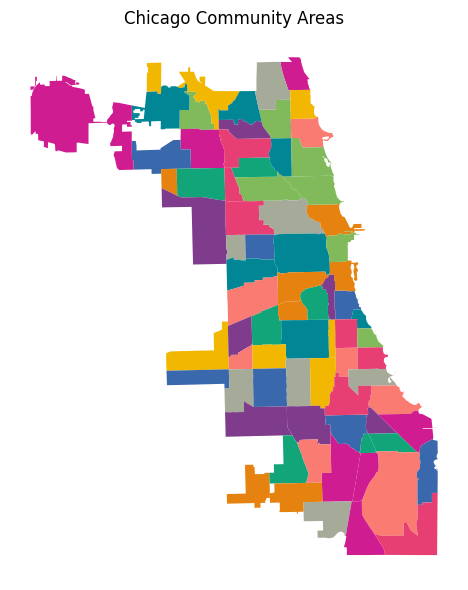

In [3]:
ax = chicago.plot(
    column="community", 
    categorical=True, 
    cmap=colormaps.bold, 
    legend=False, figsize=(6, 6)
)
ax.set_title("Chicago Community Areas")
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 1 · Single geometry — `PointSampler`

`PointSampler` draws uniform random points inside any Shapely geometry using batch rejection sampling with Shapely 2 vectorised `contains` checks. This improves upon the past implementation in `pointpats`, which samples single points at a time. We'll sample directly from the O'Hare community area as an example, the sticky-outy round polygon on the northwest of Chicago. 

In [4]:
geom = chicago.loc[chicago.community=="OHARE"]

pts = PointSampler(n_samples=200, random_state=60666).sample(geom)

Now, `pts` is a set of randomly-sampled points from within the O'Hare area boundary. 

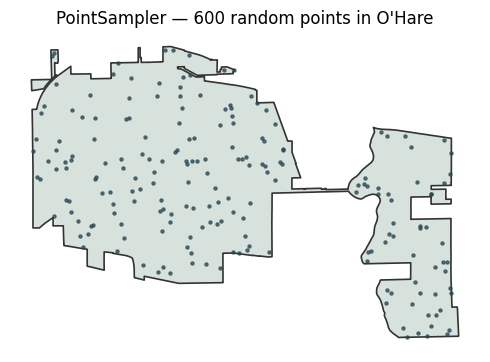

In [5]:
fig, ax = plt.subplots(figsize=(5, 6))
geom.geometry.plot(ax=ax, color="#d8e2dc", edgecolor="#333", linewidth=1.2)
ax.scatter(pts.geometry.x, pts.geometry.y, s=5, c="#264653", alpha=0.7, zorder=3)
ax.set_title("PointSampler — 600 random points in O'Hare")
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.show()

Note how the points are a bit clumpy---they tend to cluster together visually in a few places. We can smooth this out using the quasi-random sequences for sampling points. The `quasi_random=` keyword argument replaces the uniform RNG with a quasi-random sequence that is more effective for space-filling sampling; `sobol`, `halton`, and `r2` sequences are supported. 

The comparison below samples **300 points** from Staten Island three ways. Quasi-random sequences fill the space more evenly — notice fewer clusters and gaps compared to the random draw.

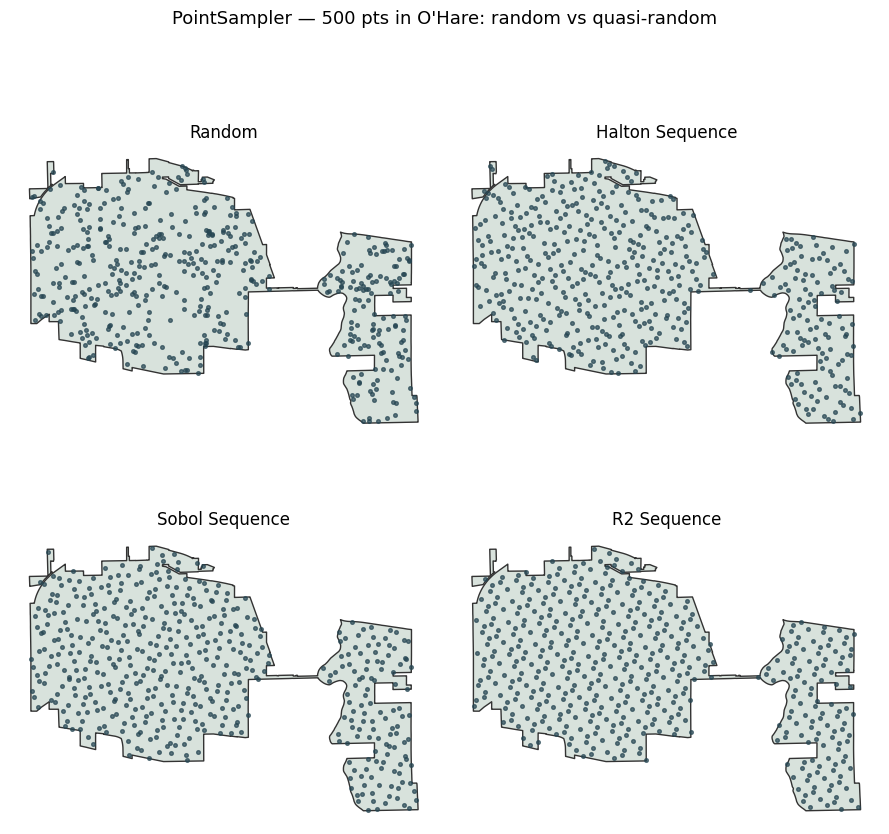

In [6]:
configs = [
    (None,     "Random"),
    ("halton", "Halton Sequence"),
    ("sobol", "Sobol Sequence"),
    ("r2",     "R2 Sequence"),
]

fig, axes = plt.subplots(2, 2, figsize=(9,9))
for ax, (seq, title) in zip(axes.flat, configs):
    geom.geometry.plot(ax=ax, color="#d8e2dc", edgecolor="#333", linewidth=1)
    p = PointSampler(500, quasi_random=seq, random_state=85711).sample(geom)
    ax.scatter(p.geometry.x, p.geometry.y, s=7, c="#264653", alpha=0.7, zorder=3)
    ax.set_title(title, fontsize=12)
    ax.set_aspect("equal"); ax.axis("off")

plt.suptitle("PointSampler — 500 pts in O'Hare: random vs quasi-random",
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

We can also sample across all of chicago easily: 

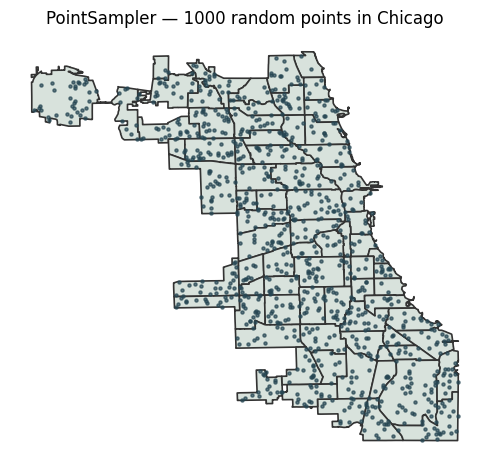

In [7]:
fig, ax = plt.subplots()
pts_all = PointSampler(n_samples=1000, random_state=60622).sample(chicago)
chicago.geometry.plot(ax=ax, color="#d8e2dc", edgecolor="#333", linewidth=1.2)
ax.scatter(pts_all.geometry.x, pts_all.geometry.y, s=5, c="#264653", alpha=0.7, zorder=3)
ax.set_title("PointSampler — 1000 random points in Chicago")
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 2 · GeoDataFrame — class-aware samplers

Now, we will work in the class-aware sampling data. We'll use population as a sampling weight for now, and split the areas into income quantiles. 

In [8]:
from mapclassify import Quantiles

In [9]:
chicago['income_quantile'] = Quantiles(chicago.PerCInc14, k=5).yb

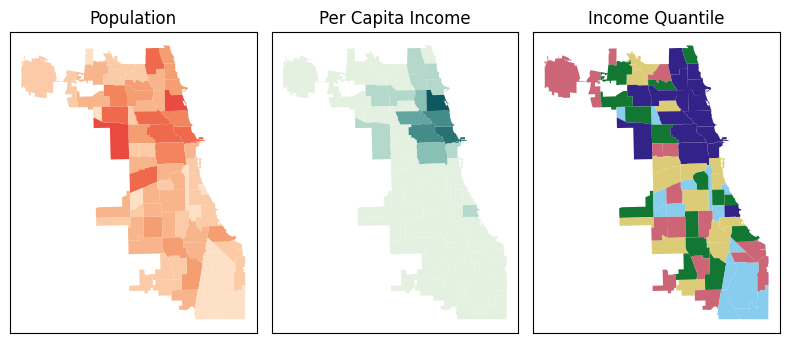

In [10]:
fig, ax = plt.subplots(1,3, figsize=(8,4))
chicago.plot("Pop2014", ax=ax[0], cmap=colormaps.peach)
chicago.plot("PerCInc14", ax=ax[1], cmap=colormaps.mint)
chicago.plot("income_quantile", ax=ax[2], cmap=colormaps.safe[:5])
for i,ax_ in enumerate(ax.flat):
    ax_.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
    ax_.set_title(['Population', 'Per Capita Income', 'Income Quantile'][i])
plt.tight_layout()
plt.show()

ConstantClassSampler — points per label:


,class_label,n points
0,0,100
1,1,100
2,2,100
3,3,100
4,4,100


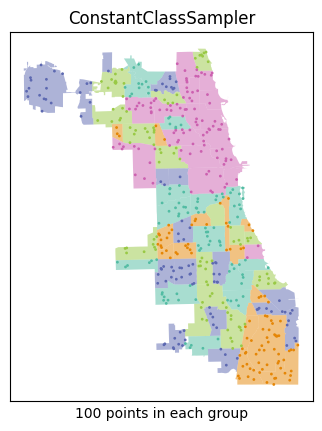

In [11]:
# ConstantClassSampler: exactly 100 pts from every income quantile
pts_const = ConstantClassSampler(n_per_class=500//5, random_state=60226).sample(
    chicago.geometry, labels=chicago.income_quantile
)
ax = chicago.plot("income_quantile", cmap=colormaps.vivid[:5], alpha=.5)
pts_const.plot("class_label", cmap=colormaps.vivid[:5], ax=ax, s=1)
ax.tick_params(labelleft=False, left=False, labelbottom=False, bottom=False)
ax.set_title("ConstantClassSampler")
ax.set_xlabel("100 points in each group")
print("ConstantClassSampler — points per label:")
pts_const.groupby("class_label").size().rename("n points").reset_index()

StratifiedClassSampler — points per area (∝ population):


,n points,Pop2014,weight
class_label,,,
0,39,213966,0.078266
1,72,394002,0.144121
2,91,497456,0.181963
3,115,628220,0.229794
4,183,1000191,0.365856


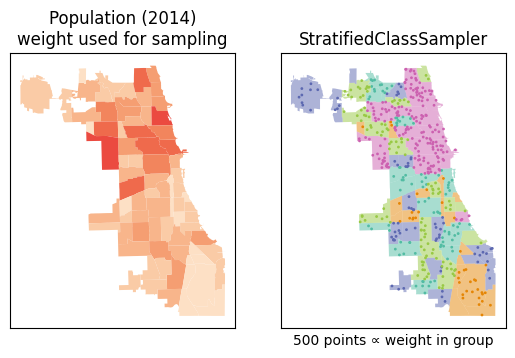

In [12]:
# StratifiedClassSampler: 500 total, allocated ∝ population
pts_strat = StratifiedClassSampler(n_samples=500, random_state=60226).sample(
    chicago.geometry, labels=chicago.income_quantile, weights=chicago.Pop2014
)
f,(pax, sax) = plt.subplots(1,2)
chicago.plot("income_quantile", cmap=colormaps.vivid[:5], alpha=.5, ax=sax)
pts_strat.plot("class_label", cmap=colormaps.vivid[:5], ax=sax, s=1)
chicago.plot("Pop2014", cmap=colormaps.peach, ax=pax)
for ax in (pax,sax):
    ax.tick_params(labelleft=False, left=False, labelbottom=False, bottom=False)
pax.set_title("Population (2014)\nweight used for sampling")
sax.set_title("StratifiedClassSampler")
sax.set_xlabel("500 points ∝ weight in group")

print("StratifiedClassSampler — points per area (∝ population):")
pts_strat.groupby("class_label").size().to_frame("n points").join(
    chicago.groupby("income_quantile").Pop2014.sum().to_frame("Pop2014").eval("weight = Pop2014/@chicago.Pop2014.sum()")
)

We see that the `ConstantClassSampler` provides samples points *at random* within areas with the same income quantile *at a constant rate*: each group gets the same number of points. In contrast, the `StratifiedClassSampler` samples from the group proportional to the population-based weight of that group. In your application, you can make weights proportional to a raster band or dataframe column.

This also works with pseudo-random sequences

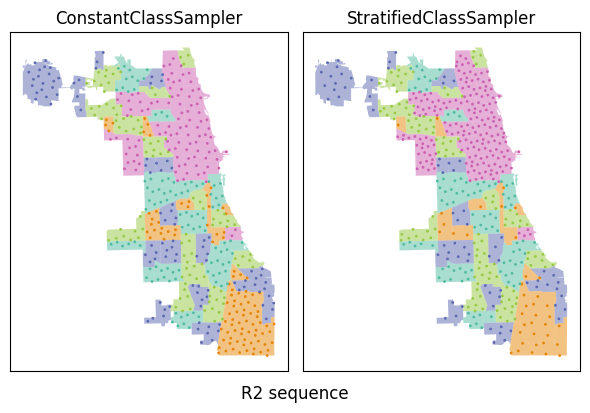

In [13]:
pts_const = ConstantClassSampler(n_per_class=100, random_state=60226, quasi_random="r2").sample(
    chicago.geometry, chicago.income_quantile
)
pts_strat = StratifiedClassSampler(n_samples=500, random_state=60226, quasi_random="r2").sample(
    chicago.geometry, chicago.income_quantile, chicago.Pop2014
)

f, (constax, stratax) = plt.subplots(1,2, figsize=(6,5))
pts_const.plot("class_label", cmap=colormaps.vivid[:5], ax=constax, s=1)
pts_strat.plot("class_label", cmap=colormaps.vivid[:5], ax=stratax, s=1)
for ax in (constax, stratax):
    chicago.plot("income_quantile", cmap=colormaps.vivid[:5], ax=ax, zorder=-1, alpha=.5)
    ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
constax.set_title("ConstantClassSampler")
stratax.set_title("StratifiedClassSampler")
f.suptitle("R2 sequence", y=0.1)
plt.tight_layout()
plt.show()

---

### `MultinomialSampler` on a GeoDataFrame

The `MultinomialSampler` works in two stages:

1. Sum *weights* within each *labels* group to get a per-class total weight $W_k$. Draw class sample counts jointly from $(n_1, n_2, \dots, n_k) \sim \text{Multinomial}(N, W_k / \sum W_k)$ — counts always sum to exactly `n_samples` but vary stochastically across runs.
2. Sample $n_k$ points uniformly from within the union of class $k$'s geometries.

This contrasts with `StratifiedClassSampler`, which allocates class counts *deterministically* using the largest-remainder (Hamilton) method. Here we'll use population again as the per-area weight, so larger areas attract proportionally more sample points — but group totals will now exhibit variation from run to run. This is most useful if you'd like to make sure that your subclass sampling counts to vary realistically from run to run, rather than being constrained to be exactly proportional to the weight. 

,n points run 1 - r2,n points run 3 - r2,n points run 2 - random,n points run 4 - random
class_label,,,,
0,42,41,41,34
1,64,72,81,76
2,85,102,92,97
3,104,107,115,115
4,205,178,171,178


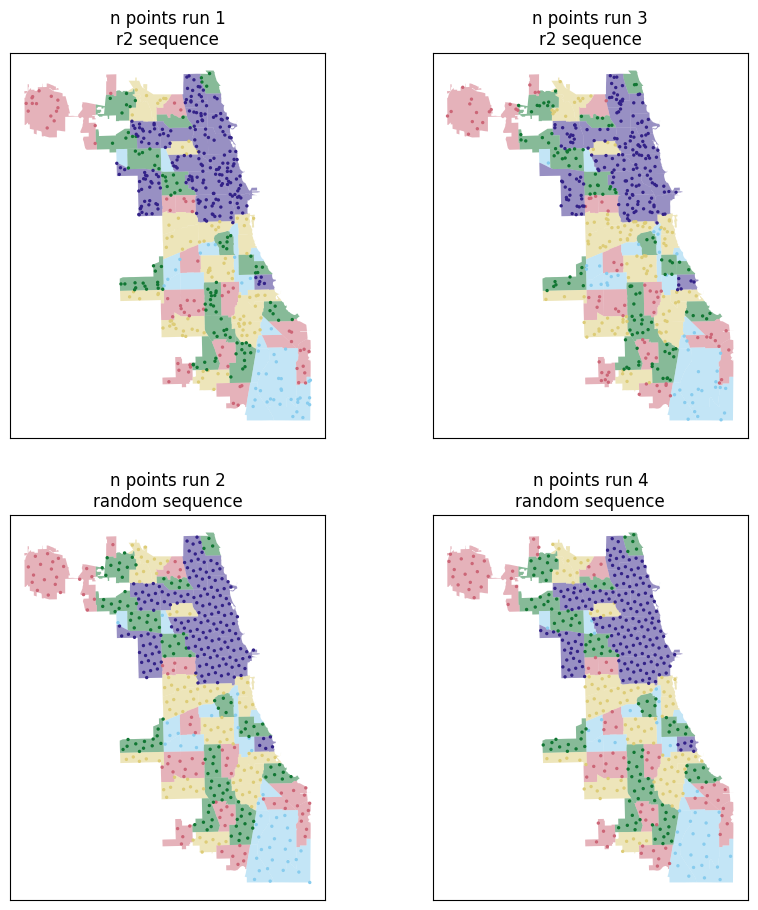

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10,11))

sizes = []
for i in range(2):
    for j in range(2):
        s = MultinomialSampler(
            n_samples=500, 
            quasi_random="r2" if i else None, 
            random_state = [60666, 60226, 60611, 60642][i+2*j]).sample(
                chicago.geometry, 
                labels=chicago.income_quantile, 
                weights=chicago.Pop2014
            )
        title = f"n points run {1+i+2*j} - {'random' if i else 'r2'}"
        sizes.append(
            s.groupby("class_label").size().to_frame(title)
        )
        chicago.plot(
            "income_quantile", 
            cmap=colormaps.safe[:5], 
            alpha=.5, 
            ax=axes[i,j]
        )
        s.plot(
            "class_label", 
            ax=axes[i,j], 
            cmap=colormaps.safe[:5], 
            s=2
        )
        axes[i,j].tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
        axes[i,j].set_title(title.replace(" - ", '\n') + " sequence")
f.tight_layout()
pandas.concat(sizes, axis=1)

---

## `PoissonSampler` — continuously-varying intensity


The `PoissonSampler` works using a spatially-varying intensity function, either specified as a callable, a geometric dataset (such as a set of polygons or a raster), or an alternative point pattern representing intensities we'd like to re-sample. We use this to define an intensity surface, where higher values should see more points being sampled from realisation to realisation.

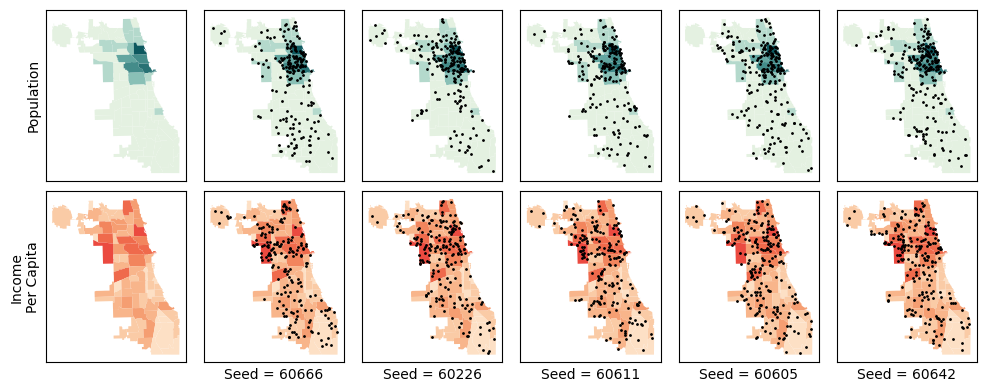

In [15]:
f,ax = plt.subplots(2,6, figsize=(10,4))
ax=ax.T
for i in range(2):
    cm = colormaps.peach if i else colormaps.mint
    col = "Pop2014" if i else "PerCInc14"
    chicago.plot(col, ax=ax[0,i], cmap=cm)
    ax[0,i].set_ylabel(['Population', 'Income\nPer Capita'][i])
    for j in range(5):
        pois = PoissonSampler(
            n_expected=200, 
            random_state=[60666, 60226, 60611, 60605, 60642][j]
        ).sample(chicago.geometry, intensity=chicago[col])
        chicago.plot(col, ax=ax[j+1,i], cmap=cm)
        pois.plot(ax=ax[j+1,i], markersize=1, color='k')
        if i:
            ax[j+1,1].set_xlabel(f"Seed = {[60666, 60226, 60611, 60605, 60642][j]}")
for ax_ in ax.flat:
    ax_.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
f.tight_layout()
plt.show()

Notice for the population maps, the points concentrate fairly thoroughly in the center near the more populated areas. However, for the per capita income map, points cluster in the *richer* areas. 

This works as well allowing a callable intensity function, a raster, or supplying a point pattern that you'd like to imitate using a kernel density estimate. We'll show the first two here and show raster sampling across all classes in the next section. 

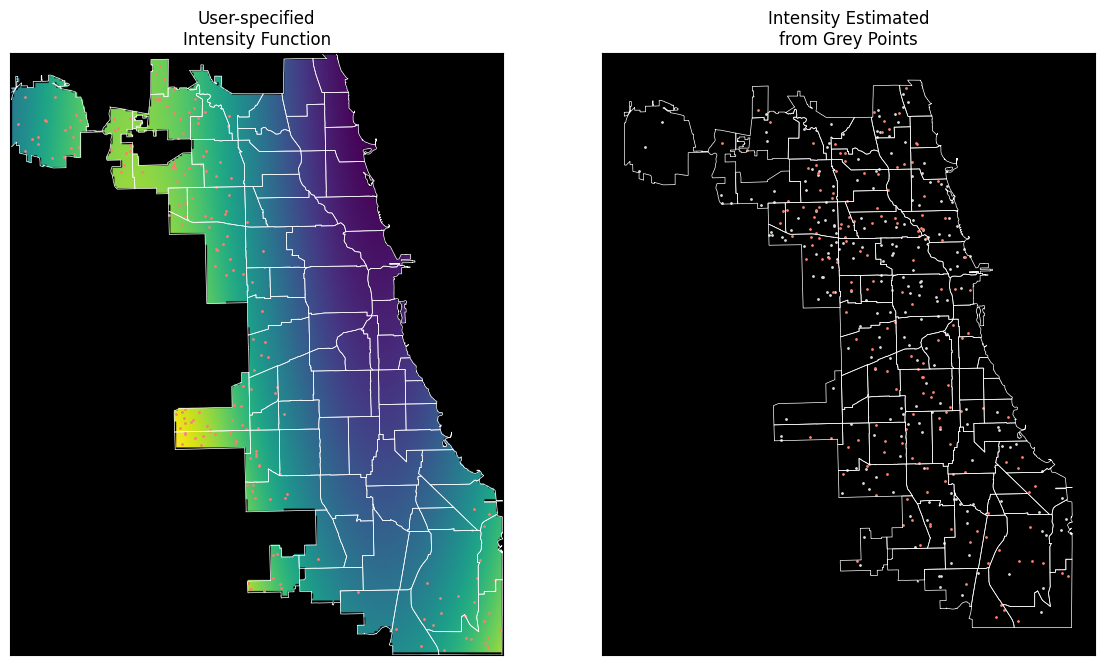

In [16]:
f,ax = plt.subplots(1,2, figsize=(14,14))
xmin, ymin, xmax, ymax = chicago.total_bounds
chihull = chicago.union_all("coverage")


def pattern_function(x,y):
    dx = x+87.524137
    dy = y-42.023
    a = 8*(dy)**2+np.sin((dx)/.41597 * np.pi*2)+dx*dy*2
    in_area = chihull.contains(
        geopandas.points_from_xy(x=x.flatten(),y=y.flatten())
    ).reshape(x.shape)
    a[~in_area] = np.nan
    return a


(x,y) = np.meshgrid(np.linspace(xmin, xmax, num=256), np.linspace(ymin, ymax, num=256))

callable_pattern = PoissonSampler(
    n_expected=180, 
    random_state=60666
).sample(chicago.geometry, intensity=pattern_function)

mimic_pattern = PoissonSampler(
    n_expected=180, 
    random_state=60666
).sample(chicago.geometry, intensity=pois #from the last loop above
)

for i in range(2):
    if not i:
        ax[i].imshow(
            pattern_function(x.flatten(),y.flatten()).reshape(256,256)[::-1],
            extent=[xmin,xmax,ymin,ymax]
        )
        chicago.geometry.boundary.plot(ax=ax[i], color='white', linewidth=.5)
    else:
        chicago.geometry.boundary.plot(ax=ax[i], color='white', linewidth=.5)
        pois.plot(ax=ax[i], color='gainsboro', markersize=1)
    
    [callable_pattern,mimic_pattern][i].plot(ax=ax[i], markersize=1, color='salmon')
    ax[i].tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
    ax[i].set_facecolor("black")
    ax[i].set_title(['User-specified\nIntensity Function', 'Intensity Estimated\nfrom Grey Points'][i])

---
## 4 Raster — rasterized chicago

The functionality also works with raster. To show this, we rasterize the chicago GeoDataFrame into two in-memory GeoTIFFs:

| Raster | Content | Sampler |
|--------|---------|---------|
| `class_mf` | Integer `BoroCode` (1–5) per pixel | `ConstantClassSampler` |
| `weight_mf` | `Shape_Area` of each borough's pixels | `StratifiedClassSampler`, `MultinomialSampler`, `PoissonSampler` |

Sampling occurs over the dataset, while the weights/labels currnetly require arrays to be read into data. 

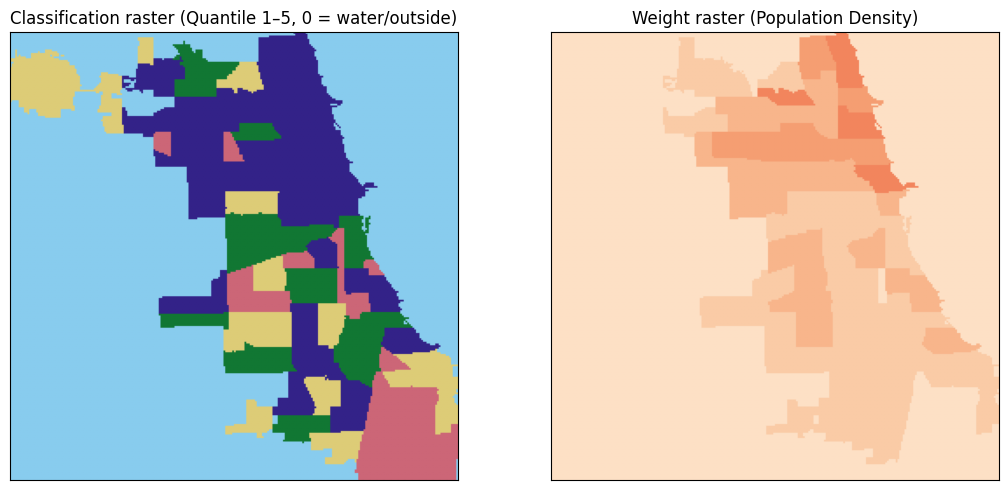

In [17]:
nrows, ncols = 256, 256
bounds = chicago.total_bounds           # (minx, miny, maxx, maxy) in EPSG:2263
transform = from_bounds(*bounds, ncols, nrows)


def _rasterize(shapes, dtype, fill=0):
    mf = MemoryFile()
    with mf.open(driver="GTiff", height=nrows, width=ncols, count=1,
                 dtype=dtype, transform=transform, crs=chicago.crs,
                 nodata=fill) as ds:
        arr = rasterize(shapes, out_shape=(nrows, ncols), transform=transform,
                        fill=fill, dtype=dtype)
        ds.write(arr[np.newaxis])
    return mf


# Classification raster (BoroCode as integer class label)
class_mf = _rasterize(
    zip(chicago.geometry, chicago.income_quantile.astype("uint8")+1), "uint8", fill=0
)

# Weight raster (population density)
norm_area = (chicago.Pop2014 / 1000 / chicago.to_crs(chicago.estimate_utm_crs()).geometry.area).values
weight_mf = _rasterize(
    zip(chicago.geometry, norm_area.astype("float32")), "float32", fill=0.0
)

# Preview
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
with class_mf.open() as ds:
    arr_c = ds.read(1)
with weight_mf.open() as ds:
    arr_w = ds.read(1)

axes[0].imshow(arr_c, cmap=colormaps.safe[:5], vmin=0, vmax=5, origin="upper")
axes[0].set_title("Classification raster (Quantile 1–5, 0 = water/outside)")
axes[1].imshow(arr_w, cmap=colormaps.peach[:5], origin="upper")
axes[1].set_title("Weight raster (Population Density)")
for ax in axes: 
    ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
plt.tight_layout() 
plt.show()

In [18]:
with class_mf.open() as ds:
    class_arr = ds.read(1)
    pts_const_r = ConstantClassSampler(n_per_class=100, random_state=60666).sample(ds, class_arr)
    pts_strat_r = StratifiedClassSampler(n_samples=500, random_state=60605).sample(
        ds, labels=class_arr, weights=class_arr>0,
    )
    pts_multi_r = MultinomialSampler(n_samples=500, random_state=60642).sample(
        ds, labels=class_arr, weights=class_arr>0,
    )
    with weight_mf.open() as wds:
        # to sample within chicago's polygon, we use the geometry
        pts_poiss_r = PoissonSampler(n_expected=500, random_state=60611).sample(
            chicago.geometry, intensity=wds
        )
        # to sample just directly from the raster, set geometry=None as the first argument. 

pix,cix = chicago.sindex.query(pts_poiss_r.geometry.values, predicate='within')
pts_poiss_r['class_label'] = chicago.income_quantile.iloc[cix].values+1

pandas.concat((
    pts_const_r.groupby("class_label").size().rename("Constant samples per class"),
    pts_strat_r.groupby("class_label").size().rename("Stratified samples per class"),
    pts_multi_r.groupby("class_label").size().rename("Multinomial samples per class"),
    pts_poiss_r.groupby("class_label").size().rename("Poisson samples per class")),
    axis=1
)

,Constant samples per class,Stratified samples per class,Multinomial samples per class,Poisson samples per class
class_label,,,,
1,100,78,91,35
2,100,109,108,82
3,100,99,101,86
4,100,100,96,121
5,100,114,104,187


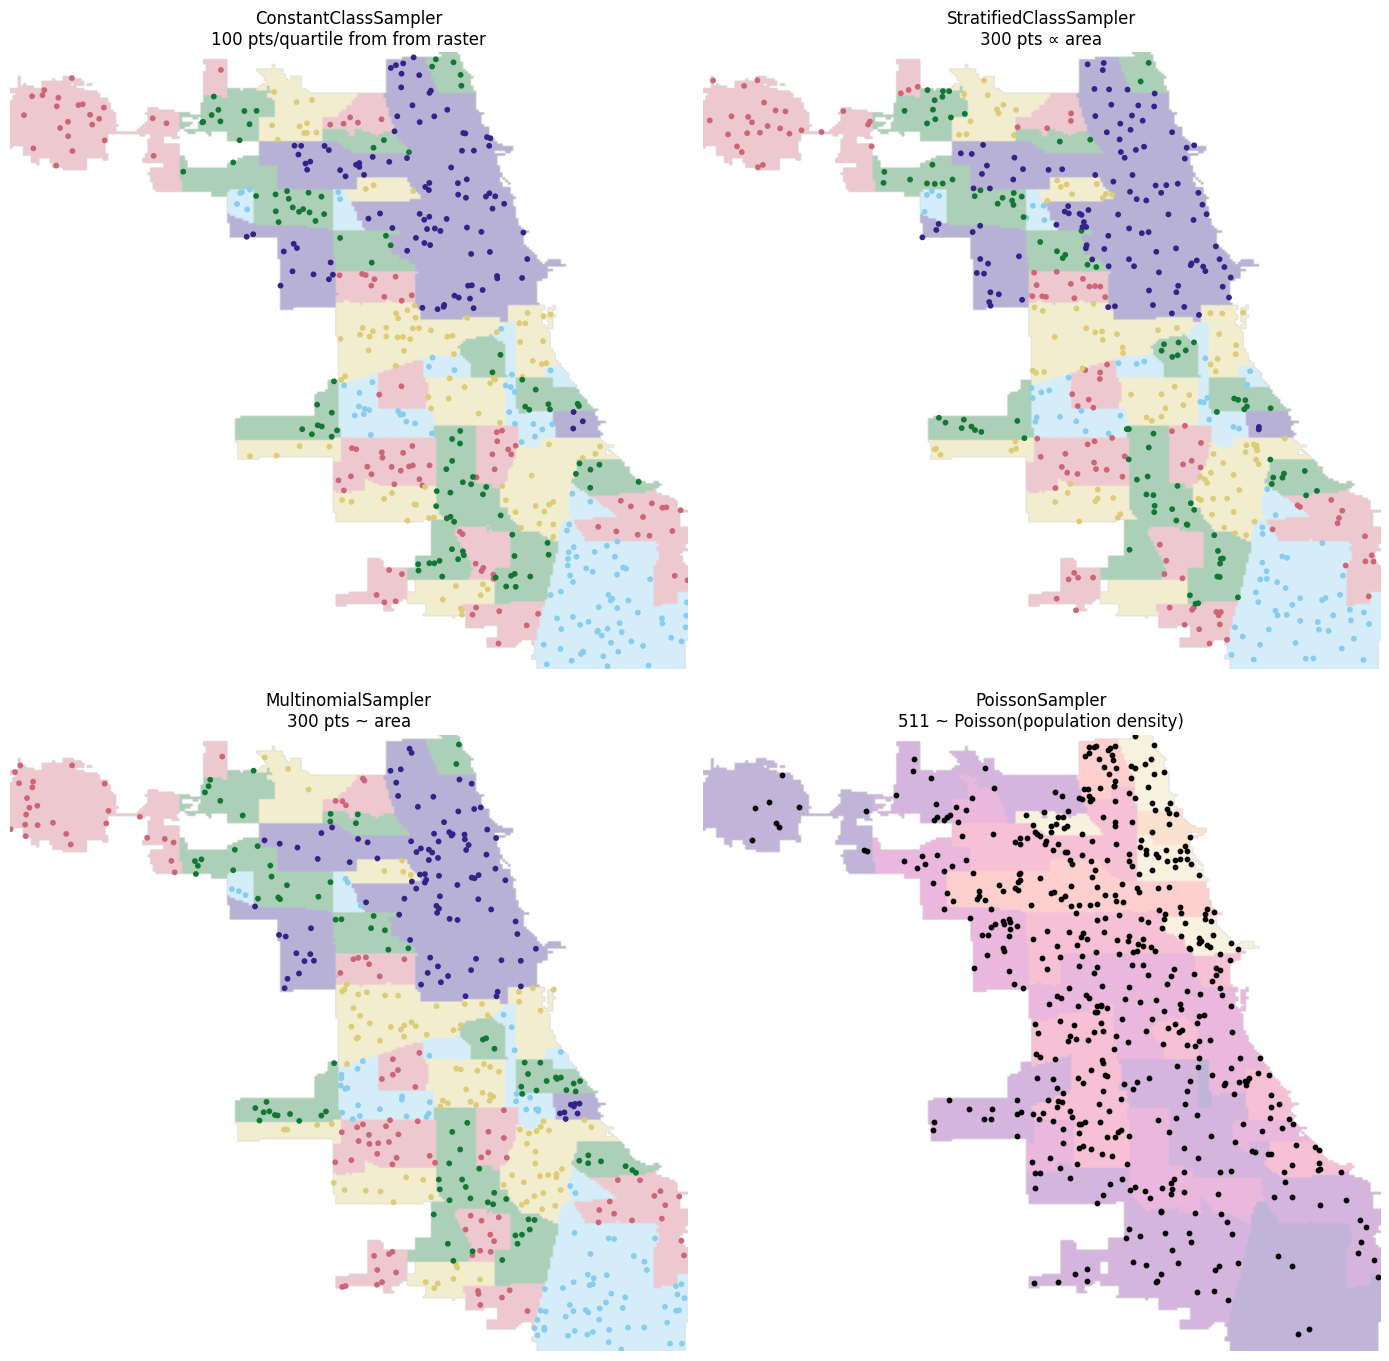

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14,14))
for ax, pts, title in [
    (axes.flat[0], pts_const_r,
     "ConstantClassSampler\n100 pts/quartile from from raster"),
    (axes.flat[1], pts_strat_r,
     "StratifiedClassSampler\n300 pts ∝ area"),
    (axes.flat[2], pts_multi_r,
     "MultinomialSampler\n300 pts ~ area"),
     (axes.flat[3], pts_poiss_r,
     f"PoissonSampler\n{len(pts_poiss_r)} ~ Poisson(population density)")
]:
    if not title.startswith("P"):
        c = (arr_c+1).copy().astype(float)
        c[arr_c == 0] = np.nan
        ax.imshow(c, 
                  cmap=colormaps.safe[:5], 
                  origin="upper", 
                  extent=[xmin,xmax,ymin,ymax], 
                  alpha=0.35
                )
        pts.plot("class_label", ax=ax, cmap=colormaps.safe[:5], markersize=10)
    else:
        w = (arr_w/arr_w.max()).copy()
        w[arr_c==0] = np.nan
        ax.imshow(w, cmap=colormaps.agsunset,
                origin="upper", extent=[xmin,xmax,ymin,ymax], alpha=0.35)
        pts.plot(ax=ax, color='black', markersize=10)
    ax.set_title(title, fontsize=12)
    ax.set_aspect("equal")
    ax.axis("off")
plt.tight_layout()
plt.show()